## 1. 데이터 로드

In [12]:
import pandas as pd
import numpy as np

occ  = pd.read_csv('csi_features_occupied.csv')
uocc = pd.read_csv('csi_features_unoccupied.csv')
df   = pd.concat([occ, uocc], ignore_index=True)

print(f'재실: {len(occ)}행  공실: {len(uocc)}행  합계: {len(df)}행')
df.head()

재실: 606행  공실: 600행  합계: 1206행


,label,rx,start,rssi_mean,rssi_std,amp_mean,amp_std_time,subcarrier_var_mean,subcarrier_std_mean,temporal_diff_mean_abs,...,window_var,spectral_total_power,low_band_ratio,mid_band_ratio,dominant_freq_idx,corr_mean_abs,spectral_entropy,peak_to_peak,skewness,kurtosis
0,occupied,RX2,0,-43.20,0.948683,13.330252,1.375304,11.356703,3.258676,0.421570,...,1.891461,1.891461,0.699357,0.271926,0.031250,0.510913,4.283111,8.242604,-1.678089,4.816867
1,occupied,RX1,0,-52.16,1.254751,12.465112,1.295252,15.845901,3.896587,0.301267,...,1.677677,1.677677,0.729027,0.247488,0.031250,0.402147,4.105193,7.731445,-1.369974,4.529206
2,occupied,RX3,0,-41.45,0.898610,11.464364,0.877445,22.609159,4.627463,0.258771,...,0.769910,0.769910,0.557864,0.405132,0.015625,0.608308,4.935919,5.500643,-2.487304,9.722371
3,occupied,RX2,100,-44.62,1.405560,12.796632,1.071785,10.057989,3.094802,0.361433,...,1.148722,1.148722,0.629066,0.341873,0.007812,0.411852,4.729134,7.026325,-2.188492,7.518004
4,occupied,RX1,100,-50.06,1.515388,12.688499,1.043142,15.469226,3.748480,0.318122,...,1.088146,1.088146,0.545402,0.416283,0.007812,0.420216,4.879763,7.171392,-3.067937,13.058200


## 2. 전처리

In [13]:
df['label_bin'] = (df['label'] == 'occupied').astype(int)
df = pd.get_dummies(df, columns=['rx'], prefix='rx')

drop_cols    = ['label', 'start', 'label_bin']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].astype(float)
y = df['label_bin']

print(f'피처 수: {len(feature_cols)}')
print(f'재실={y.sum()}  공실={len(y)-y.sum()}')

피처 수: 21
재실=606  공실=600


## 3. 피처 분포 비교

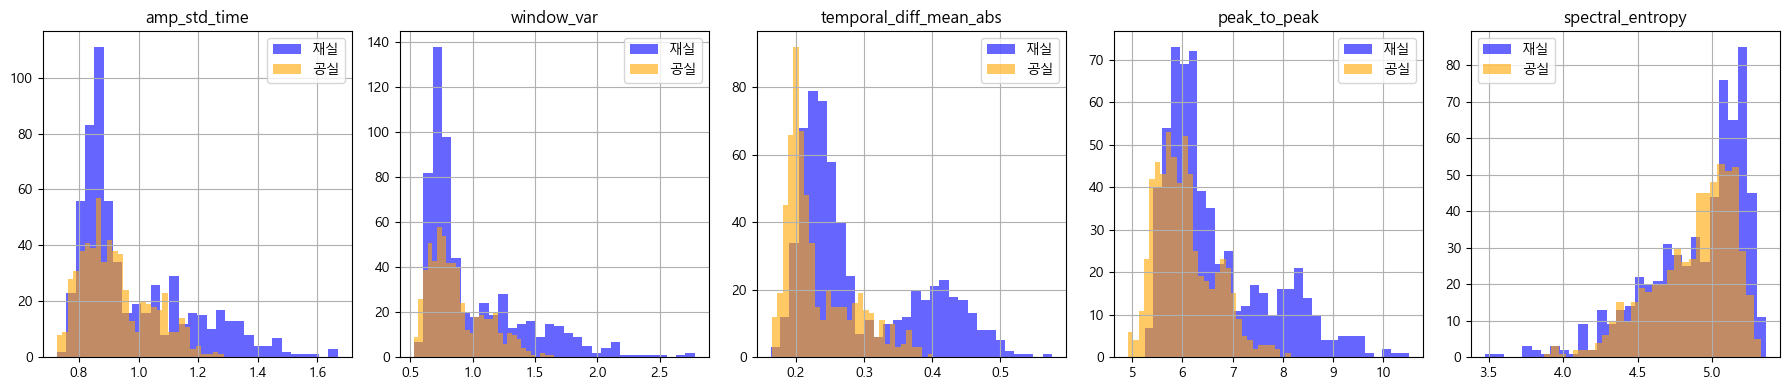

In [14]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

key_feats = ["amp_std_time", "window_var", "temporal_diff_mean_abs", "peak_to_peak", "spectral_entropy"]
fig, axes = plt.subplots(1, len(key_feats), figsize=(18, 4))

for ax, feat in zip(axes, key_feats):
    df[df["label_bin"]==1][feat].hist(ax=ax, alpha=0.6, label="재실", bins=30, color="blue")
    df[df["label_bin"]==0][feat].hist(ax=ax, alpha=0.6, label="공실", bins=30, color="orange")
    ax.set_title(feat)
    ax.legend()

plt.tight_layout()
plt.savefig("eda_boxplot.png", dpi=100)
plt.show()


## 4. 모델 비교 (5-Fold CV)

In [15]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

candidates = {
    'RandomForest': RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2,
        class_weight='balanced', random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        eval_metric='logloss', random_state=42, n_jobs=-1),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=10, gamma='scale',
                    probability=True, class_weight='balanced', random_state=42)),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in candidates.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1', n_jobs=-1)
    results[name] = scores
    print(f'{name:20s}  F1={scores.mean():.4f} +- {scores.std():.4f}')

RandomForest          F1=0.9983 +- 0.0020
GradientBoosting      F1=0.9951 +- 0.0048
XGBoost               F1=0.9967 +- 0.0048
SVM                   F1=0.9958 +- 0.0053


## 5. 최고 모델 선택 + 확률 보정

보정 전 신뢰도: [1.    0.999 0.976 1.    1.    0.997 1.    1.    1.    0.999]
보정 후 신뢰도: [1.    1.    0.961 1.    1.    1.    1.    1.    1.    1.   ]
              precision    recall  f1-score   support

          공실       1.00      1.00      1.00       600
          재실       1.00      1.00      1.00       606

    accuracy                           1.00      1206
   macro avg       1.00      1.00      1.00      1206
weighted avg       1.00      1.00      1.00      1206



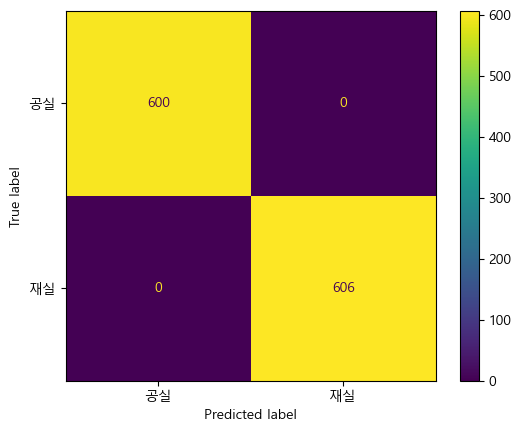

In [16]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

raw_model = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    eval_metric="logloss", random_state=42, n_jobs=-1
)

calibrated_model = CalibratedClassifierCV(raw_model, method="isotonic", cv=5)
calibrated_model.fit(X, y)

raw_model.fit(X, y)
sample = X.iloc[:10]
print("보정 전 신뢰도:", raw_model.predict_proba(sample)[:, 1].round(3))
print("보정 후 신뢰도:", calibrated_model.predict_proba(sample)[:, 1].round(3))

y_pred = calibrated_model.predict(X)
print(classification_report(y, y_pred, target_names=["공실", "재실"]))

cm = confusion_matrix(y, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["공실", "재실"]).plot()
plt.savefig("confusion_matrix.png", dpi=100)
plt.show()


## 6. 피처 중요도

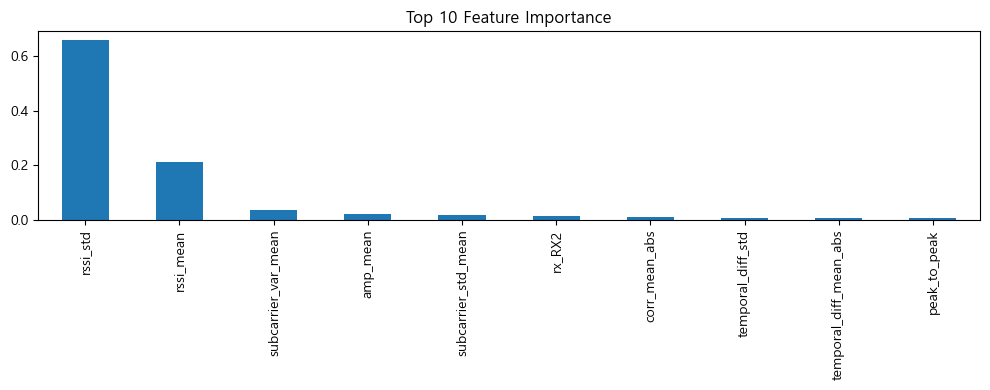

rssi_std                  0.657258
rssi_mean                 0.212966
subcarrier_var_mean       0.034391
amp_mean                  0.022257
subcarrier_std_mean       0.017498
rx_RX2                    0.011626
corr_mean_abs             0.010308
temporal_diff_std         0.007376
temporal_diff_mean_abs    0.007181
peak_to_peak              0.006046
dtype: float32


In [17]:
base = getattr(raw_model, 'named_steps', {}).get('svm', raw_model)
if hasattr(base, 'feature_importances_'):
    fi = pd.Series(base.feature_importances_, index=feature_cols).sort_values(ascending=False)
    fi.head(10).plot(kind='bar', figsize=(10, 4), title='Top 10 Feature Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=100)
    plt.show()
    print(fi.head(10))
else:
    print('피처 중요도 미지원 모델')

## 7. 모델 저장

In [18]:
import joblib

joblib.dump(calibrated_model, 'model.pkl')
joblib.dump(feature_cols,     'feature_cols.pkl')

print('저장 완료: model.pkl (보정된 모델)')
print('저장 완료: feature_cols.pkl')

저장 완료: model.pkl (보정된 모델)
저장 완료: feature_cols.pkl
